# Soft-Clipped Read Analysis

During initial BAM inspection, multiple alignments contained  soft-clipped sequence segments within their CIGAR strings.

In targeted RNA sequencing, soft clipping may arise from:
- incomplete adapter trimming,
- RNA processing events,
- fusion or rearrangement breakpoints, <- very interesting
- alignment ambiguity,
- sequencing artifacts,
- or structurally complex genomic regions.

This analysis focuses specifically on relatively large soft-clipped segments (>15 bp) to identify recurrent clipping patterns and evaluate whether they likely reflect technical artifacts or biologically meaningful events.

The name of the game here is to identify what soft clipping remnants are categorically technical noise, or real observable biological changes. 

In [1]:
from pathlib import Path
import pysam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bam_dir = Path("../data/bam")
bam_files = sorted(bam_dir.glob("*.bam"))

fig_dir = Path("../results/figures")
table_dir = Path("../results/tables")

bam_files

[PosixPath('../data/bam/sample1.bam'),
 PosixPath('../data/bam/sample2.bam'),
 PosixPath('../data/bam/sample3.bam')]

lets take a look at the soft clips.

In [2]:
softclip_rows = []

for bam_file in bam_files:
    
    sample = bam_file.stem
    bam = pysam.AlignmentFile(bam_file, "rb")
    
    for read in bam.fetch(until_eof=True):
        
        if read.is_unmapped:
            continue
        
        cigar = read.cigartuples
        
        if cigar is None:
            continue
        
        # left soft clip
        if cigar[0][0] == 4:
            left_clip = cigar[0][1]
        else:
            left_clip = 0
        
        # right soft clip
        if cigar[-1][0] == 4:
            right_clip = cigar[-1][1]
        else:
            right_clip = 0
        
        max_clip = max(left_clip, right_clip)
        
        if max_clip >= 15:
            
            softclip_rows.append({
                "sample": sample,
                "chrom": read.reference_name,
                "start": read.reference_start,
                "mapq": read.mapping_quality,
                "cigar": read.cigarstring,
                "left_clip": left_clip,
                "right_clip": right_clip,
                "max_clip": max_clip,
                "read_length": read.query_length
            })

softclip_df = pd.DataFrame(softclip_rows)

softclip_df.head()

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai


,sample,chrom,start,mapq,cigar,left_clip,right_clip,max_clip,read_length
0,sample1,1,3188498,255,17S52M,17,0,17,69
1,sample1,1,3188498,255,19S52M,19,0,19,71
2,sample1,1,8581777,255,52M17S,0,17,17,69
3,sample1,1,8581777,255,52M17S,0,17,17,69
4,sample1,1,8746683,255,18S84M,18,0,18,102


In [5]:
softclip_summary = (
    softclip_df
    .groupby("sample")
    .agg(
        n_softclipped_reads=("cigar", "size"),
        median_softclip=("max_clip", "median"),
        max_softclip=("max_clip", "max"),
        median_mapq=("mapq", "median")
    )
    .reset_index()
)

softclip_summary.to_csv(
    table_dir / "softclip_summary.csv",
    index=False
)

softclip_summary

,sample,n_softclipped_reads,median_softclip,max_softclip,median_mapq
0,sample1,13259,21.0,150,255.0
1,sample2,41892,22.0,151,255.0
2,sample3,21327,22.0,151,255.0


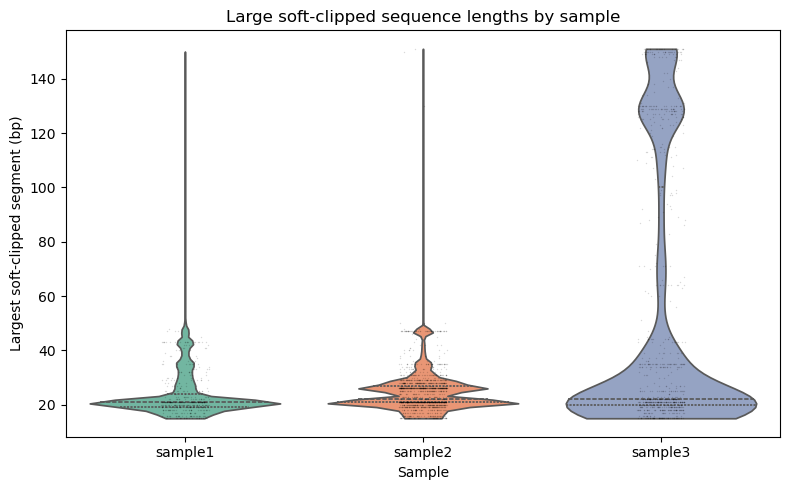

In [8]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=softclip_df,
    x="sample",
    y="max_clip",
    hue="sample",
    inner="quartile",
    palette="Set2",
    legend=False,
    cut=0
)

sns.stripplot(
    data=softclip_df.sample(min(3000, len(softclip_df)), random_state=1),
    x="sample",
    y="max_clip",
    color="black",
    alpha=0.15,
    size=1
)

plt.title("Large soft-clipped sequence lengths by sample")
plt.xlabel("Sample")
plt.ylabel("Largest soft-clipped segment (bp)")

plt.tight_layout()
plt.savefig(fig_dir / "softclip_length_violin_points_by_sample.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
softclip_df["bin"] = (softclip_df["start"] // 1000) * 1000

softclip_loci = (
    softclip_df
    .groupby(["sample", "chrom", "bin"])
    .agg(
        n_softclipped_reads=("max_clip", "size"),
        median_softclip=("max_clip", "median"),
        max_softclip=("max_clip", "max")
    )
    .reset_index()
    .sort_values(["sample", "n_softclipped_reads"], ascending=[True, False])
)

softclip_loci["region"] = (
    "chr" + softclip_loci["chrom"].astype(str) + ":" +
    softclip_loci["bin"].astype(str)
)

softclip_loci.to_csv(table_dir / "softclip_loci_summary.csv", index=False)

softclip_loci.head(20)

,sample,chrom,bin,n_softclipped_reads,median_softclip,max_softclip,region
486,sample1,GL000220.1,113000,681,21.0,38,chrGL000220.1:113000
498,sample1,GL000220.1,157000,670,21.0,38,chrGL000220.1:157000
66,sample1,11,69456000,544,21.0,51,chr11:69456000
67,sample1,11,69457000,460,21.0,51,chr11:69457000
482,sample1,GL000220.1,109000,453,21.0,48,chrGL000220.1:109000
326,sample1,4,25665000,443,43.0,48,chr4:25665000
494,sample1,GL000220.1,153000,418,21.0,48,chrGL000220.1:153000
483,sample1,GL000220.1,110000,401,21.0,51,chrGL000220.1:110000
180,sample1,19,34890000,355,21.0,44,chr19:34890000
495,sample1,GL000220.1,154000,344,21.0,51,chrGL000220.1:154000


In [11]:
# Load previously generated region-gene annotations
gene_lookup = pd.read_csv(
    table_dir / "top_shared_enriched_regions_gene_annotations.csv"
)

gene_lookup = gene_lookup[
    ["region", "gene_name"]
].drop_duplicates()

# Convert softclip loci into matching region format
softclip_loci["region_full"] = (
    "chr" + softclip_loci["chrom"].astype(str) + ":" +
    softclip_loci["bin"].astype(str) + "-" +
    (softclip_loci["bin"] + 999).astype(str)
)

# Merge gene names
softclip_annot = softclip_loci.merge(
    gene_lookup,
    left_on="region_full",
    right_on="region",
    how="left"
)

softclip_annot["gene_label"] = np.where(
    softclip_annot["gene_name"].isna(),
    softclip_annot["region_full"],
    softclip_annot["gene_name"] + " (" + softclip_annot["region_full"] + ")"
)

softclip_annot.head()

,sample,chrom,bin,n_softclipped_reads,median_softclip,max_softclip,region_x,region_full,region_y,gene_name,gene_label
0,sample1,GL000220.1,113000,681,21.0,38,chrGL000220.1:113000,chrGL000220.1:113000-113999,NaN,NaN,chrGL000220.1:113000-113999
1,sample1,GL000220.1,157000,670,21.0,38,chrGL000220.1:157000,chrGL000220.1:157000-157999,NaN,NaN,chrGL000220.1:157000-157999
2,sample1,11,69456000,544,21.0,51,chr11:69456000,chr11:69456000-69456999,chr11:69456000-69456999,CCND1,CCND1 (chr11:69456000-69456999)
3,sample1,11,69457000,460,21.0,51,chr11:69457000,chr11:69457000-69457999,chr11:69457000-69457999,CCND1,CCND1 (chr11:69457000-69457999)
4,sample1,GL000220.1,109000,453,21.0,48,chrGL000220.1:109000,chrGL000220.1:109000-109999,NaN,NaN,chrGL000220.1:109000-109999


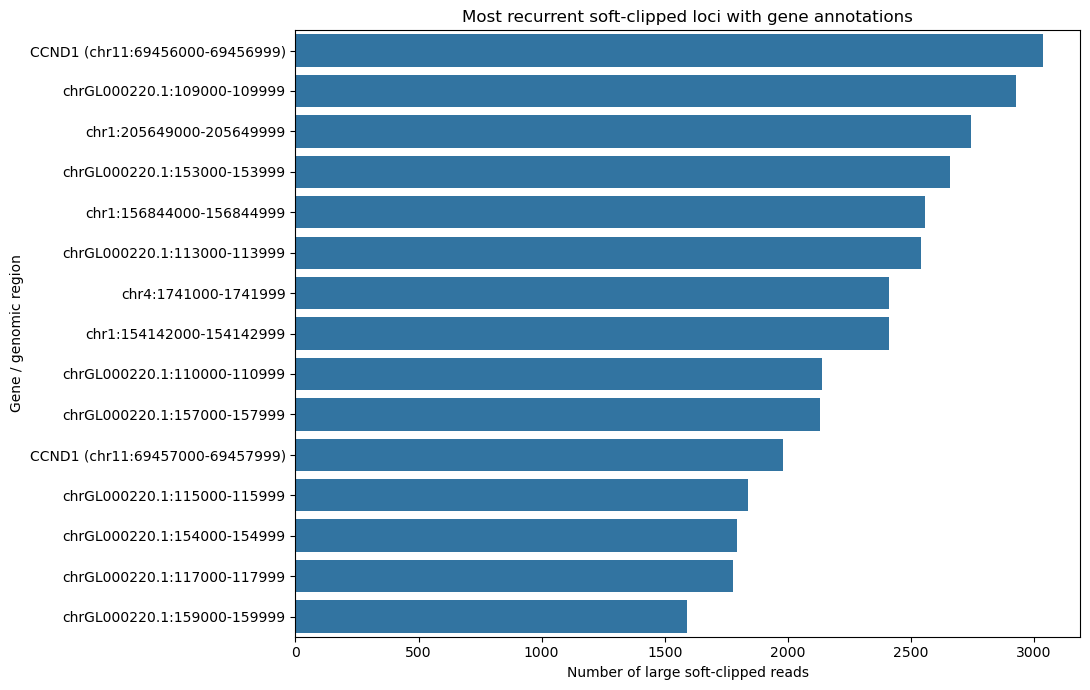

In [12]:
top_softclip_genes = (
    softclip_annot
    .groupby("gene_label")
    .agg(
        total_softclipped_reads=("n_softclipped_reads", "sum")
    )
    .reset_index()
    .sort_values("total_softclipped_reads", ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_softclip_genes,
    x="total_softclipped_reads",
    y="gene_label"
)

plt.title("Most recurrent soft-clipped loci with gene annotations")
plt.xlabel("Number of large soft-clipped reads")
plt.ylabel("Gene / genomic region")

plt.tight_layout()

plt.savefig(
    fig_dir / "top_softclip_gene_annotated_loci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Overall Conclusions

This analysis identified strong targeted enrichment across a limited set of recurrent genomic loci and genes, including **CCND1, FGFR1, AXL, MET, EGFR, RAF1, GNAS, and RAB7A**. Molecule-aware deduplication using `mb` barcodes demonstrated that raw sequencing depth substantially overestimated molecular abundance in some regions, particularly within sample3, which exhibited elevated amplification redundancy and reduced barcode complexity.

Variant analysis identified recurrent candidate variants within several enriched genes, most notably shared FGFR1 substitutions observed across all three samples. Additional sample-specific candidate variants were detected within multiple cancer-associated loci, although interpretation remains exploratory because the data derive from targeted RNA sequencing rather than matched DNA sequencing.

Soft-clipped read analysis further demonstrated that large clipping events were not randomly distributed across the genome. Instead, recurrent clustering occurred at highly enriched target loci, particularly around CCND1-associated regions, suggesting a combination of structured transcript complexity, alignment ambiguity, repetitive sequence mapping, and possible technical artifacts.

Collectively, the data support a technically successful targeted sequencing assay with biologically structured enrichment patterns, while also highlighting substantial sample-specific technical differences that should be considered during downstream interpretation.